In [1]:
import pandas as pd
import numpy as np
import datetime
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
raw_mosquito_data = pd.read_csv('../data/GR_MSQ_culex_2011-2022.csv', encoding = enc)

In [7]:
raw_mosquito_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13138 entries, 0 to 13137
Data columns (total 62 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trap_id               11056 non-null  object 
 1   station_id            13138 non-null  object 
 2   x                     13138 non-null  float64
 3   y                     13138 non-null  float64
 4   dt_placement          13138 non-null  object 
 5   week                  12549 non-null  float64
 6   month                 12549 non-null  float64
 7   year                  13138 non-null  int64  
 8   country_code          13138 non-null  object 
 9   nuts0_code            13138 non-null  int64  
 10  nuts0_name            13138 non-null  object 
 11  nuts1_code            13138 non-null  object 
 12  nuts1_name            13138 non-null  object 
 13  nuts2_code            13138 non-null  object 
 14  nuts2_name            13138 non-null  object 
 15  nuts3_code         

In [8]:
missing = describe_dataframe(raw_mosquito_data)

In [9]:
drop_cols = ['trap_id', 'station_id', 'country_code', 'nuts0_code', 'nuts0_name', 'nuts1_code', 'nuts1_name', 
             'nuts2_code', 'nuts3_code', 'nuts3_name', 'lau1_municipality', 'lau2_settlement', 'trap_type', 
             'culex pipiens', 'no_pools','poolsize', 'no_pos_pools','wnv_mir', 'max_wind','min_wind','mean_wind' ]
            
raw_mosquito_data.drop(columns=drop_cols, inplace=True)

In [10]:
raw_mosquito_data

,x,y,dt_placement,week,month,year,nuts2_name,culex spp.,ndvi,ndwi,ndmi,ndbi,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,ndmi_mean,ndmi_std,ndbi_mean,ndbi_std,lst_day,lst_night,sp_cnt_1km,biol_cnt_1km,wc_l_1km,pg_area_1km,fs_area_1km,wc_mean_dist_1000,coast_mean_dist_1000,dem_mean_1km,slope_mean_1km,aspect_mean_1km,waw_mean_1km,flow_accu_1km,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,22.730024,40.708914,2021-05-17,21.0,5.0,2021,CENTRAL MACEDONIA,0.0,0.286502,-0.311660,-0.038524,0.038524,0.238997,0.045694,-0.268164,0.045641,-0.025400,0.052210,0.025400,0.052210,15492.0,14263.0,12.0,0.0,16678.868658,1586.000000,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,2.05,3.20,329.50,14118.583333,14468.785714,14733.285714,14969.230769
1,22.730024,40.708914,2021-05-31,23.0,5.0,2021,CENTRAL MACEDONIA,85.0,0.315331,-0.292070,0.075190,-0.075190,0.267370,0.044368,-0.272323,0.021341,0.041806,0.083038,-0.041806,0.083038,15358.0,14382.0,12.0,0.0,16678.868658,1586.000000,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,19.25,19.25,348.75,14118.583333,14468.785714,14733.285714,14969.230769
2,22.730024,40.708914,2021-06-14,25.0,6.0,2021,CENTRAL MACEDONIA,1107.0,0.310484,-0.280968,0.040238,-0.040238,0.303681,0.077164,-0.288144,0.032391,0.026281,0.094782,-0.026281,0.094782,15099.0,NaN,12.0,0.0,16678.868658,1586.000000,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,33.30,33.75,382.50,14118.583333,14468.785714,14733.285714,14969.230769
3,22.730024,40.708914,2021-06-28,27.0,6.0,2021,CENTRAL MACEDONIA,0.0,0.397766,-0.371749,0.063872,-0.063872,0.366396,0.143708,-0.351256,0.088096,0.060600,0.125426,-0.060600,0.125426,15606.0,14770.0,12.0,0.0,16678.868658,1586.000000,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,4.80,6.65,389.15,14118.583333,14468.785714,14733.285714,14969.230769
4,22.730024,40.708914,2021-07-12,29.0,7.0,2021,CENTRAL MACEDONIA,482.0,0.440151,-0.421065,0.107648,-0.107648,0.392860,0.155651,-0.380361,0.103538,0.088033,0.144470,-0.088033,0.144470,15516.0,14864.0,12.0,0.0,16678.868658,1586.000000,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,0.60,0.80,389.95,14118.583333,14468.785714,14733.285714,14969.230769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13133,21.404054,38.624749,2022-08-27,NaN,NaN,2022,WESTERN GREECE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15137.0,14832.0,0.0,0.0,0.000000,0.000000,0.0,1228.701664,15743.110000,74.823014,3.709523,212.501108,0.000255,227.029476,34.70,41.90,432.50,14238.235294,14405.800000,14537.941176,14997.071429
13134,20.805060,38.870754,2022-08-27,NaN,NaN,2022,WESTERN GREECE,NaN,0.269003,-0.296256,-0.110691,0.110691,0.311989,0.095536,-0.316616,0.052598,-0.026932,0.101024,0.026932,0.101024,14930.0,14683.0,7.0,0.0,2790.701384,7019.178447,0.0,186.534754,710.633500,19.355742,7.217212,145.900041,8.976672,1097.234812,7.50,11.70,519.00,14160.631579,14306.214286,14379.588235,14616.368421
13135,21.164111,38.864111,2022-08-27,NaN,NaN,2022,WESTERN GREECE,NaN,0.177672,-0.247896,-0.113881,0.113881,0.233878,0.161969,-0.218976,0.232995,-0.028018,0.124530,0.028018,0.124530,15088.0,14597.0,0.0,0.0,0.000000,0.000000,0.0,5514.596072,70.710680,113.421136,29.182177,133.704784,9.864483,68.246182,31.60,36.60,423.80,14069.150000,14243.722222,14300.650000,14717.187500
13136,21.231982,38.452619,2022-08-27,NaN,NaN,2022,WESTERN GREECE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15079.0,14679.0,0.0,0.0,3702.594394,11934.604215,0.0,377.581882,6722.397000,43.692797,10.892221,124.503172,0.257559,36.031225,10.20,15.20,432.10,14198.500000,14362.176471,14423.000000,14861.944444


In [11]:
raw_mosquito_data.dropna(subset=['culex spp.'], inplace=True)

In [12]:
raw_mosquito_data['dt_placement'] = pd.to_datetime(raw_mosquito_data['dt_placement'])
raw_mosquito_data['day'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.day)
raw_mosquito_data['month'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.month)
raw_mosquito_data['year'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.year)
raw_mosquito_data['week'] = raw_mosquito_data.apply(lambda row: datetime.date(row['year'], row['month'], row['day']).isocalendar().week, axis=1)

raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'day', 31)
raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'month', 12)
raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'week', 53)

raw_mosquito_data = fillna(raw_mosquito_data,{'acc_rainfall_1week':0, 'acc_rainfall_2week':0, 'acc_rainfall_jan':0})

raw_mosquito_data.rename(columns={"culex spp.": "mosq_now", 'nuts2_name': 'nuts2'}, inplace = True)

In [13]:
raw_mosquito_data

,x,y,dt_placement,week,month,year,nuts2,mosq_now,ndvi,ndwi,ndmi,ndbi,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,ndmi_mean,ndmi_std,ndbi_mean,ndbi_std,lst_day,lst_night,sp_cnt_1km,biol_cnt_1km,wc_l_1km,pg_area_1km,fs_area_1km,wc_mean_dist_1000,coast_mean_dist_1000,dem_mean_1km,slope_mean_1km,aspect_mean_1km,waw_mean_1km,flow_accu_1km,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,day,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,22.730024,40.708914,2021-05-17,20,5,2021,CENTRAL MACEDONIA,0.0,0.286502,-0.311660,-0.038524,0.038524,0.238997,0.045694,-0.268164,0.045641,-0.025400,0.052210,0.025400,0.052210,15492.0,14263.0,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,2.05,3.20,329.50,14118.583333,14468.785714,14733.285714,14969.230769,17,-2.993631e-01,-0.954139,5.000000e-01,-0.866025,0.696551,-0.717507
1,22.730024,40.708914,2021-05-31,22,5,2021,CENTRAL MACEDONIA,85.0,0.315331,-0.292070,0.075190,-0.075190,0.267370,0.044368,-0.272323,0.021341,0.041806,0.083038,-0.041806,0.083038,15358.0,14382.0,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,19.25,19.25,348.75,14118.583333,14468.785714,14733.285714,14969.230769,31,-2.449294e-16,1.000000,5.000000e-01,-0.866025,0.508531,-0.861044
2,22.730024,40.708914,2021-06-14,24,6,2021,CENTRAL MACEDONIA,1107.0,0.310484,-0.280968,0.040238,-0.040238,0.303681,0.077164,-0.288144,0.032391,0.026281,0.094782,-0.026281,0.094782,15099.0,NaN,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,33.30,33.75,382.50,14118.583333,14468.785714,14733.285714,14969.230769,14,2.993631e-01,-0.954139,1.224647e-16,-1.000000,0.292057,-0.956401
3,22.730024,40.708914,2021-06-28,26,6,2021,CENTRAL MACEDONIA,0.0,0.397766,-0.371749,0.063872,-0.063872,0.366396,0.143708,-0.351256,0.088096,0.060600,0.125426,-0.060600,0.125426,15606.0,14770.0,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,4.80,6.65,389.15,14118.583333,14468.785714,14733.285714,14969.230769,28,-5.712682e-01,0.820763,1.224647e-16,-1.000000,0.059241,-0.998244
4,22.730024,40.708914,2021-07-12,28,7,2021,CENTRAL MACEDONIA,482.0,0.440151,-0.421065,0.107648,-0.107648,0.392860,0.155651,-0.380361,0.103538,0.088033,0.144470,-0.088033,0.144470,15516.0,14864.0,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,0.60,0.80,389.95,14118.583333,14468.785714,14733.285714,14969.230769,12,6.513725e-01,-0.758758,-5.000000e-01,-0.866025,-0.176890,-0.984231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12543,22.954067,40.648580,2022-08-24,34,8,2022,CENTRAL MACEDONIA,1.0,0.108800,-0.157839,-0.079579,0.079579,0.125762,0.038774,-0.177657,0.049420,-0.084464,0.030286,0.084464,0.030286,NaN,NaN,0.0,0.0,2514.936715,0.0,0.0,543.982084,1802.776000,167.390733,8.043573,213.880372,0.000000,138.001542,51.90,57.20,469.20,14074.764706,14294.200000,14491.384615,14936.588235,24,-9.884683e-01,0.151428,-8.660254e-01,-0.500000,-0.776524,-0.630088
12544,22.935970,40.660236,2022-08-24,34,8,2022,CENTRAL MACEDONIA,6.0,0.142357,-0.180150,-0.049146,0.049146,0.130708,0.039193,-0.167007,0.039839,-0.050729,0.014443,0.050729,0.014443,NaN,NaN,0.0,0.0,6696.381407,0.0,0.0,175.347815,2549.510000,93.688859,4.607163,204.432806,0.000000,3232.999005,51.90,57.20,469.20,14087.800000,14340.428571,14567.500000,14990.882353,24,-9.884683e-01,0.151428,-8.660254e-01,-0.500000,-0.776524,-0.630088
12545,22.926086,40.675754,2022-08-24,34,8,2022,CENTRAL MACEDONIA,4.0,0.175213,-0.217523,-0.043891,0.043891,0.158012,0.054620,-0.194171,0.047478,-0.041421,0.025661,0.041421,0.025661,NaN,NaN,0.0,0.0,7056.758641,0.0,0.0,189.348351,3640.055000,107.330465,

In [14]:
reorder = [
 'nuts2',
 'x',
 'y',
 'dt_placement',
 'day',
 'month',
 'week',
 'year',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'ndvi',
 'ndwi',
 'ndmi',
 'ndbi',
 'ndvi_mean',
 'ndvi_std',
 'ndwi_mean',
 'ndwi_std',
 'ndmi_mean',
 'ndmi_std',
 'ndbi_mean',
 'ndbi_std',
 'lst_day',
 'lst_night',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'acc_rainfall_1week',
 'acc_rainfall_2week',
 'acc_rainfall_jan',
 'sp_cnt_1km',
 'biol_cnt_1km',
 'wc_l_1km',
 'pg_area_1km',
 'fs_area_1km',
 'wc_mean_dist_1000',
 'coast_mean_dist_1000',
 'dem_mean_1km',
 'slope_mean_1km',
 'aspect_mean_1km',
 'waw_mean_1km',
 'flow_accu_1km',
 'mosq_now'
 ]

In [15]:
dataset = raw_mosquito_data[reorder].copy()

In [16]:
dataset

,nuts2,x,y,dt_placement,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,ndvi,ndwi,ndmi,ndbi,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,ndmi_mean,ndmi_std,ndbi_mean,ndbi_std,lst_day,lst_night,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,sp_cnt_1km,biol_cnt_1km,wc_l_1km,pg_area_1km,fs_area_1km,wc_mean_dist_1000,coast_mean_dist_1000,dem_mean_1km,slope_mean_1km,aspect_mean_1km,waw_mean_1km,flow_accu_1km,mosq_now
0,CENTRAL MACEDONIA,22.730024,40.708914,2021-05-17,17,5,20,2021,-2.993631e-01,-0.954139,5.000000e-01,-0.866025,0.696551,-0.717507,0.286502,-0.311660,-0.038524,0.038524,0.238997,0.045694,-0.268164,0.045641,-0.025400,0.052210,0.025400,0.052210,15492.0,14263.0,14118.583333,14468.785714,14733.285714,14969.230769,2.05,3.20,329.50,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,0.0
1,CENTRAL MACEDONIA,22.730024,40.708914,2021-05-31,31,5,22,2021,-2.449294e-16,1.000000,5.000000e-01,-0.866025,0.508531,-0.861044,0.315331,-0.292070,0.075190,-0.075190,0.267370,0.044368,-0.272323,0.021341,0.041806,0.083038,-0.041806,0.083038,15358.0,14382.0,14118.583333,14468.785714,14733.285714,14969.230769,19.25,19.25,348.75,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,85.0
2,CENTRAL MACEDONIA,22.730024,40.708914,2021-06-14,14,6,24,2021,2.993631e-01,-0.954139,1.224647e-16,-1.000000,0.292057,-0.956401,0.310484,-0.280968,0.040238,-0.040238,0.303681,0.077164,-0.288144,0.032391,0.026281,0.094782,-0.026281,0.094782,15099.0,NaN,14118.583333,14468.785714,14733.285714,14969.230769,33.30,33.75,382.50,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,1107.0
3,CENTRAL MACEDONIA,22.730024,40.708914,2021-06-28,28,6,26,2021,-5.712682e-01,0.820763,1.224647e-16,-1.000000,0.059241,-0.998244,0.397766,-0.371749,0.063872,-0.063872,0.366396,0.143708,-0.351256,0.088096,0.060600,0.125426,-0.060600,0.125426,15606.0,14770.0,14118.583333,14468.785714,14733.285714,14969.230769,4.80,6.65,389.15,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,0.0
4,CENTRAL MACEDONIA,22.730024,40.708914,2021-07-12,12,7,28,2021,6.513725e-01,-0.758758,-5.000000e-01,-0.866025,-0.176890,-0.984231,0.440151,-0.421065,0.107648,-0.107648,0.392860,0.155651,-0.380361,0.103538,0.088033,0.144470,-0.088033,0.144470,15516.0,14864.0,14118.583333,14468.785714,14733.285714,14969.230769,0.60,0.80,389.95,12.0,0.0,16678.868658,1586.0,0.0,241.283733,13372.276367,50.943983,4.030365,148.000384,0.034628,374.852147,482.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12543,CENTRAL MACEDONIA,22.954067,40.648580,2022-08-24,24,8,34,2022,-9.884683e-01,0.151428,-8.660254e-01,-0.500000,-0.776524,-0.630088,0.108800,-0.157839,-0.079579,0.079579,0.125762,0.038774,-0.177657,0.049420,-0.084464,0.030286,0.084464,0.030286,NaN,NaN,14074.764706,14294.200000,14491.384615,14936.588235,51.90,57.20,469.20,0.0,0.0,2514.936715,0.0,0.0,543.982084,1802.776000,167.390733,8.043573,213.880372,0.000000,138.001542,1.0
12544,CENTRAL MACEDONIA,22.935970,40.660236,2022-08-24,24,8,34,2022,-9.884683e-01,0.151428,-8.660254e-01,-0.500000,-0.776524,-0.630088,0.142357,-0.180150,-0.049146,0.049146,0.130708,0.039193,-0.167007,0.039839,-0.050729,0.014443,0.050729,0.014443,NaN,NaN,14087.800000,14340.428571,14567.500000,14990.882353,51.90,57.20,469.20,0.0,0.0,6696.381407,0.0,0.0,175.347815,2549.510000,93.688859,4.607163,204.432806,0.000000,3232.999005,6.0
12545,CENTRAL MACEDONIA,22.926086,40.675754,2022-08-24,24,8,34,2022,-9.884683e-01,0.151428,-8.660254e-01,-0.500000,-0.776524,-0.630088,0.175213,-0.217523,-0.043891,0.043891,0.158012,0.054620,-0.194171,0.047478,-0.041421,0.025661,0.041421,0.025661,NaN,

In [21]:
dataset.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [20]:
dataset['nuts2'] = dataset['nuts2'].apply(lambda x : x.replace('CENTRAL MACEDONIA', 'κεντρικης μακεδονιας'))
dataset['nuts2'] = dataset['nuts2'].apply(lambda x : x.replace('THESSALY', 'θεσσαλιας'))
dataset['nuts2'] = dataset['nuts2'].apply(lambda x : x.replace('CRETE', 'κρητης'))
dataset['nuts2'] = dataset['nuts2'].apply(lambda x : x.replace('WESTERN GREECE', 'δυτικης ελλαδας'))


<AxesSubplot:>

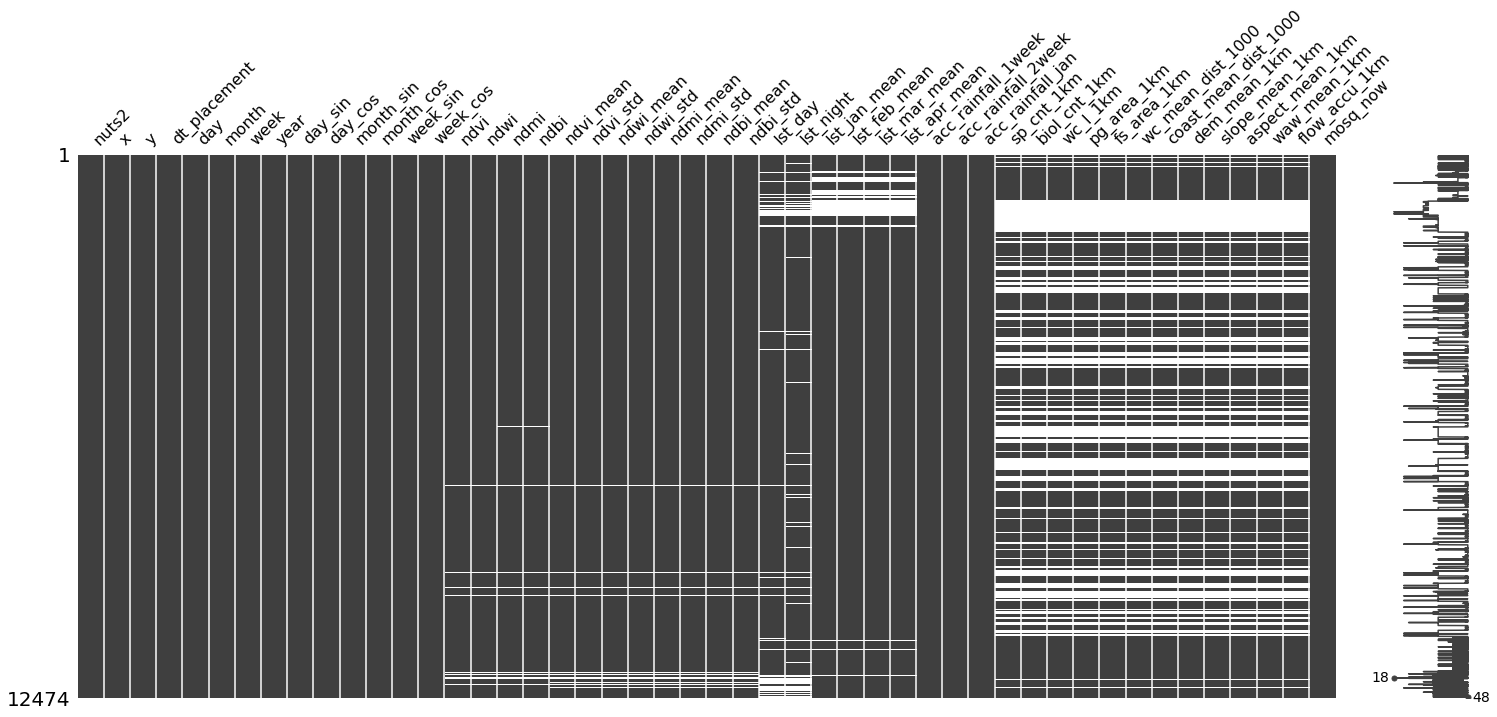

In [22]:
missingno.matrix(dataset)

In [23]:
dataset.to_csv("../data/GR_MSQ_culex_2011-2022_processed.csv", encoding = enc, index = False)